# Análisis exploratorio de incidencia delictiva en México

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('data/delitos.csv')

#### Ejercicio 1: Elige 3 estados de la república y grafica una serie de tiempo de la frecuencia abosluta de homicidios dolosos de enero 2015 a julio 2019 en estas tres entidades

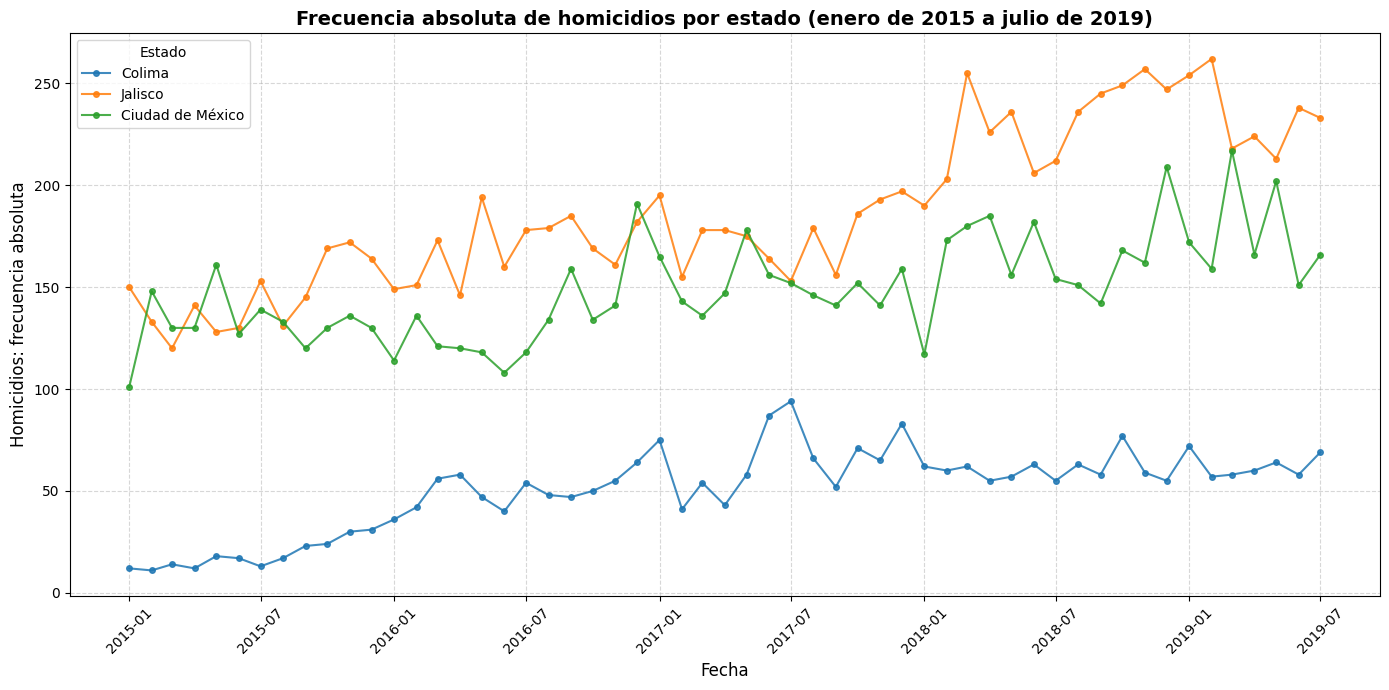

In [6]:
# Ejercicio 1: Serie de tiempo de homicidios en 3 estados elegidos (2015-01 a 2019-07)
# Nota: Como el dataset delitos.csv agrupó los tipos de homicidio (doloso/culposo) bajo 'Homicidio',
# usaremos 'Homicidio' como tipo de delito.
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el archivo
df = pd.read_csv('data/delitos.csv')

# Convertir la columna fecha a datetime antes de filtrar
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')

# Filtrar homicidios entre enero de 2015 y julio de 2019
df_homicidios = df.loc[
    (df['tipo_de_delito'] == 'Homicidio') &
    (df['fecha'] >= '2015-01-01') &
    (df['fecha'] <= '2019-07-31')
].copy()

# Seleccionar tres estados
estados_elegidos = [
    'Colima',
    'Jalisco',
    'Ciudad de México'
]

df_filtrado = df_homicidios.loc[
    df_homicidios['entidad'].isin(estados_elegidos)
].copy()

# Ordenar los datos por entidad y fecha
df_filtrado = df_filtrado.sort_values(
    by=['entidad', 'fecha']
)

# Graficar
plt.figure(figsize=(14, 7))

for estado in estados_elegidos:
    datos_estado = df_filtrado.loc[
        df_filtrado['entidad'] == estado
    ]

    plt.plot(
        datos_estado['fecha'],
        datos_estado['frecuencia'],
        label=estado,
        marker='o',
        markersize=4,
        alpha=0.85
    )

plt.title(
    'Frecuencia absoluta de homicidios por estado '
    '(enero de 2015 a julio de 2019)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Homicidios: frecuencia absoluta', fontsize=12)

plt.legend(title='Estado')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Ejercicio 2: Contetas las siguientes  preguntas:
1. ¿Cuántos homicidios dolosos hubo en Colima en el 2018?
2. ¿Cuantos robos de vehículo automotor ha habido en el 2019?
3. Obten la suma de homicidos dolosos y feminidios en toda la República Mexicana en cada año.
4. ¿En qué mes y en qué municipio ha ocurrido el mayor número de feminicidios?
5. ¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?

In [8]:
import pandas as pd

# Cargar datos
df = pd.read_csv('data/delitos.csv')

# Limpiar nombres de columnas
df.columns = df.columns.str.strip()

# Convertir fecha antes de hacer cualquier filtro
df['fecha'] = pd.to_datetime(
    df['fecha'],
    errors='coerce'
)

# Convertir frecuencia a número
df['frecuencia'] = pd.to_numeric(
    df['frecuencia'],
    errors='coerce'
).fillna(0)

# Eliminar registros cuya fecha no pudo convertirse
df = df.dropna(subset=['fecha']).copy()

# Crear variables temporales a partir de la fecha
df['anio'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['periodo'] = df['fecha'].dt.to_period('M')

print("=== RESPUESTAS A LAS PREGUNTAS DEL EJERCICIO 2 ===\n")


# ---------------------------------------------------------
# 1. Homicidios registrados en Colima durante 2018
# ---------------------------------------------------------
# Advertencia: esto incluye todos los registros clasificados
# como "Homicidio"; no distingue doloso de culposo.

df_homicidios_colima_2018 = df.loc[
    (df['entidad'] == 'Colima') &
    (df['anio'] == 2018) &
    (df['tipo_de_delito'] == 'Homicidio')
].copy()

homicidios_colima_2018 = (
    df_homicidios_colima_2018['frecuencia'].sum()
)

print(
    "1. Homicidios registrados en Colima durante 2018 "
    f"(dolosos y culposos juntos): {homicidios_colima_2018:.0f}"
)


# ---------------------------------------------------------
# 2. Robos registrados en la República Mexicana durante 2019
# ---------------------------------------------------------
# Advertencia: esto suma todos los registros clasificados como
# "Robo"; no distingue específicamente robo de vehículo.

df_robos_2019 = df.loc[
    (df['anio'] == 2019) &
    (df['tipo_de_delito'] == 'Robo')
].copy()

robos_2019 = df_robos_2019['frecuencia'].sum()

print(
    "2. Robos registrados en la República Mexicana durante "
    f"2019 (todos los tipos): {robos_2019:.0f}"
)


# ---------------------------------------------------------
# 3. Suma anual de homicidios y feminicidios en todo el país
# ---------------------------------------------------------

df_homicidios_feminicidios = df.loc[
    df['tipo_de_delito'].isin([
        'Homicidio',
        'Feminicidio'
    ])
].copy()

suma_anual = (
    df_homicidios_feminicidios
    .groupby('anio', as_index=False)['frecuencia']
    .sum()
    .rename(
        columns={
            'frecuencia': 'homicidios_y_feminicidios'
        }
    )
)

print(
    "\n3. Suma anual de homicidios y feminicidios "
    "en todo el país:"
)

display(suma_anual)


# ---------------------------------------------------------
# 4. Mes y entidad con más feminicidios
# ---------------------------------------------------------
# Primero se suman todos los registros de una misma entidad
# y un mismo mes. Después se localiza el total más alto.

df_feminicidios = df.loc[
    df['tipo_de_delito'] == 'Feminicidio'
].copy()

feminicidios_mensuales = (
    df_feminicidios
    .groupby(
        ['entidad', 'periodo'],
        as_index=False
    )['frecuencia']
    .sum()
)

if not feminicidios_mensuales.empty:

    indice_maximo_mensual = (
        feminicidios_mensuales['frecuencia'].idxmax()
    )

    max_fem_mensual = (
        feminicidios_mensuales.loc[indice_maximo_mensual]
    )

    print(
        "\n4. Registro mensual con mayor número "
        "de feminicidios:"
    )
    print(f"   Estado: {max_fem_mensual['entidad']}")
    print(f"   Mes: {max_fem_mensual['periodo']}")
    print(
        "   Cantidad: "
        f"{max_fem_mensual['frecuencia']:.0f} feminicidios"
    )

else:
    print("\n4. No se encontraron registros de feminicidio.")


# ---------------------------------------------------------
# 5. Año y entidad con más feminicidios acumulados
# ---------------------------------------------------------

feminicidios_anuales_estado = (
    df_feminicidios
    .groupby(
        ['anio', 'entidad'],
        as_index=False
    )['frecuencia']
    .sum()
)

if not feminicidios_anuales_estado.empty:

    indice_maximo_anual = (
        feminicidios_anuales_estado['frecuencia'].idxmax()
    )

    max_fem_anual = (
        feminicidios_anuales_estado.loc[indice_maximo_anual]
    )

    print(
        "\n5. Mayor número de feminicidios acumulados "
        "en un año por entidad:"
    )
    print(f"   Estado: {max_fem_anual['entidad']}")
    print(f"   Año: {int(max_fem_anual['anio'])}")
    print(
        "   Cantidad acumulada: "
        f"{max_fem_anual['frecuencia']:.0f} feminicidios"
    )

else:
    print("\n5. No se encontraron registros de feminicidio.")

=== RESPUESTAS A LAS PREGUNTAS DEL EJERCICIO 2 ===

1. Homicidios registrados en Colima durante 2018 (dolosos y culposos juntos): 726
2. Robos registrados en la República Mexicana durante 2019 (todos los tipos): 766096

3. Suma anual de homicidios y feminicidios en todo el país:


,anio,homicidios_y_feminicidios
0,2015,31744.0
1,2016,36018.0
2,2017,42068.0
3,2018,45385.0
4,2019,45822.0
5,2020,44223.0
6,2021,44960.0
7,2022,43845.0
8,2023,42846.0
9,2024,22307.0



4. Registro mensual con mayor número de feminicidios:
   Estado: México
   Mes: 2020-07
   Cantidad: 19 feminicidios

5. Mayor número de feminicidios acumulados en un año por entidad:
   Estado: México
   Año: 2020
   Cantidad acumulada: 151 feminicidios


#### Ejercicio 3: Haz una gráfica de pastel de tipos de delito. Deberás crear una gráfica para cada año. Utilzia la función subplots de matplotlib

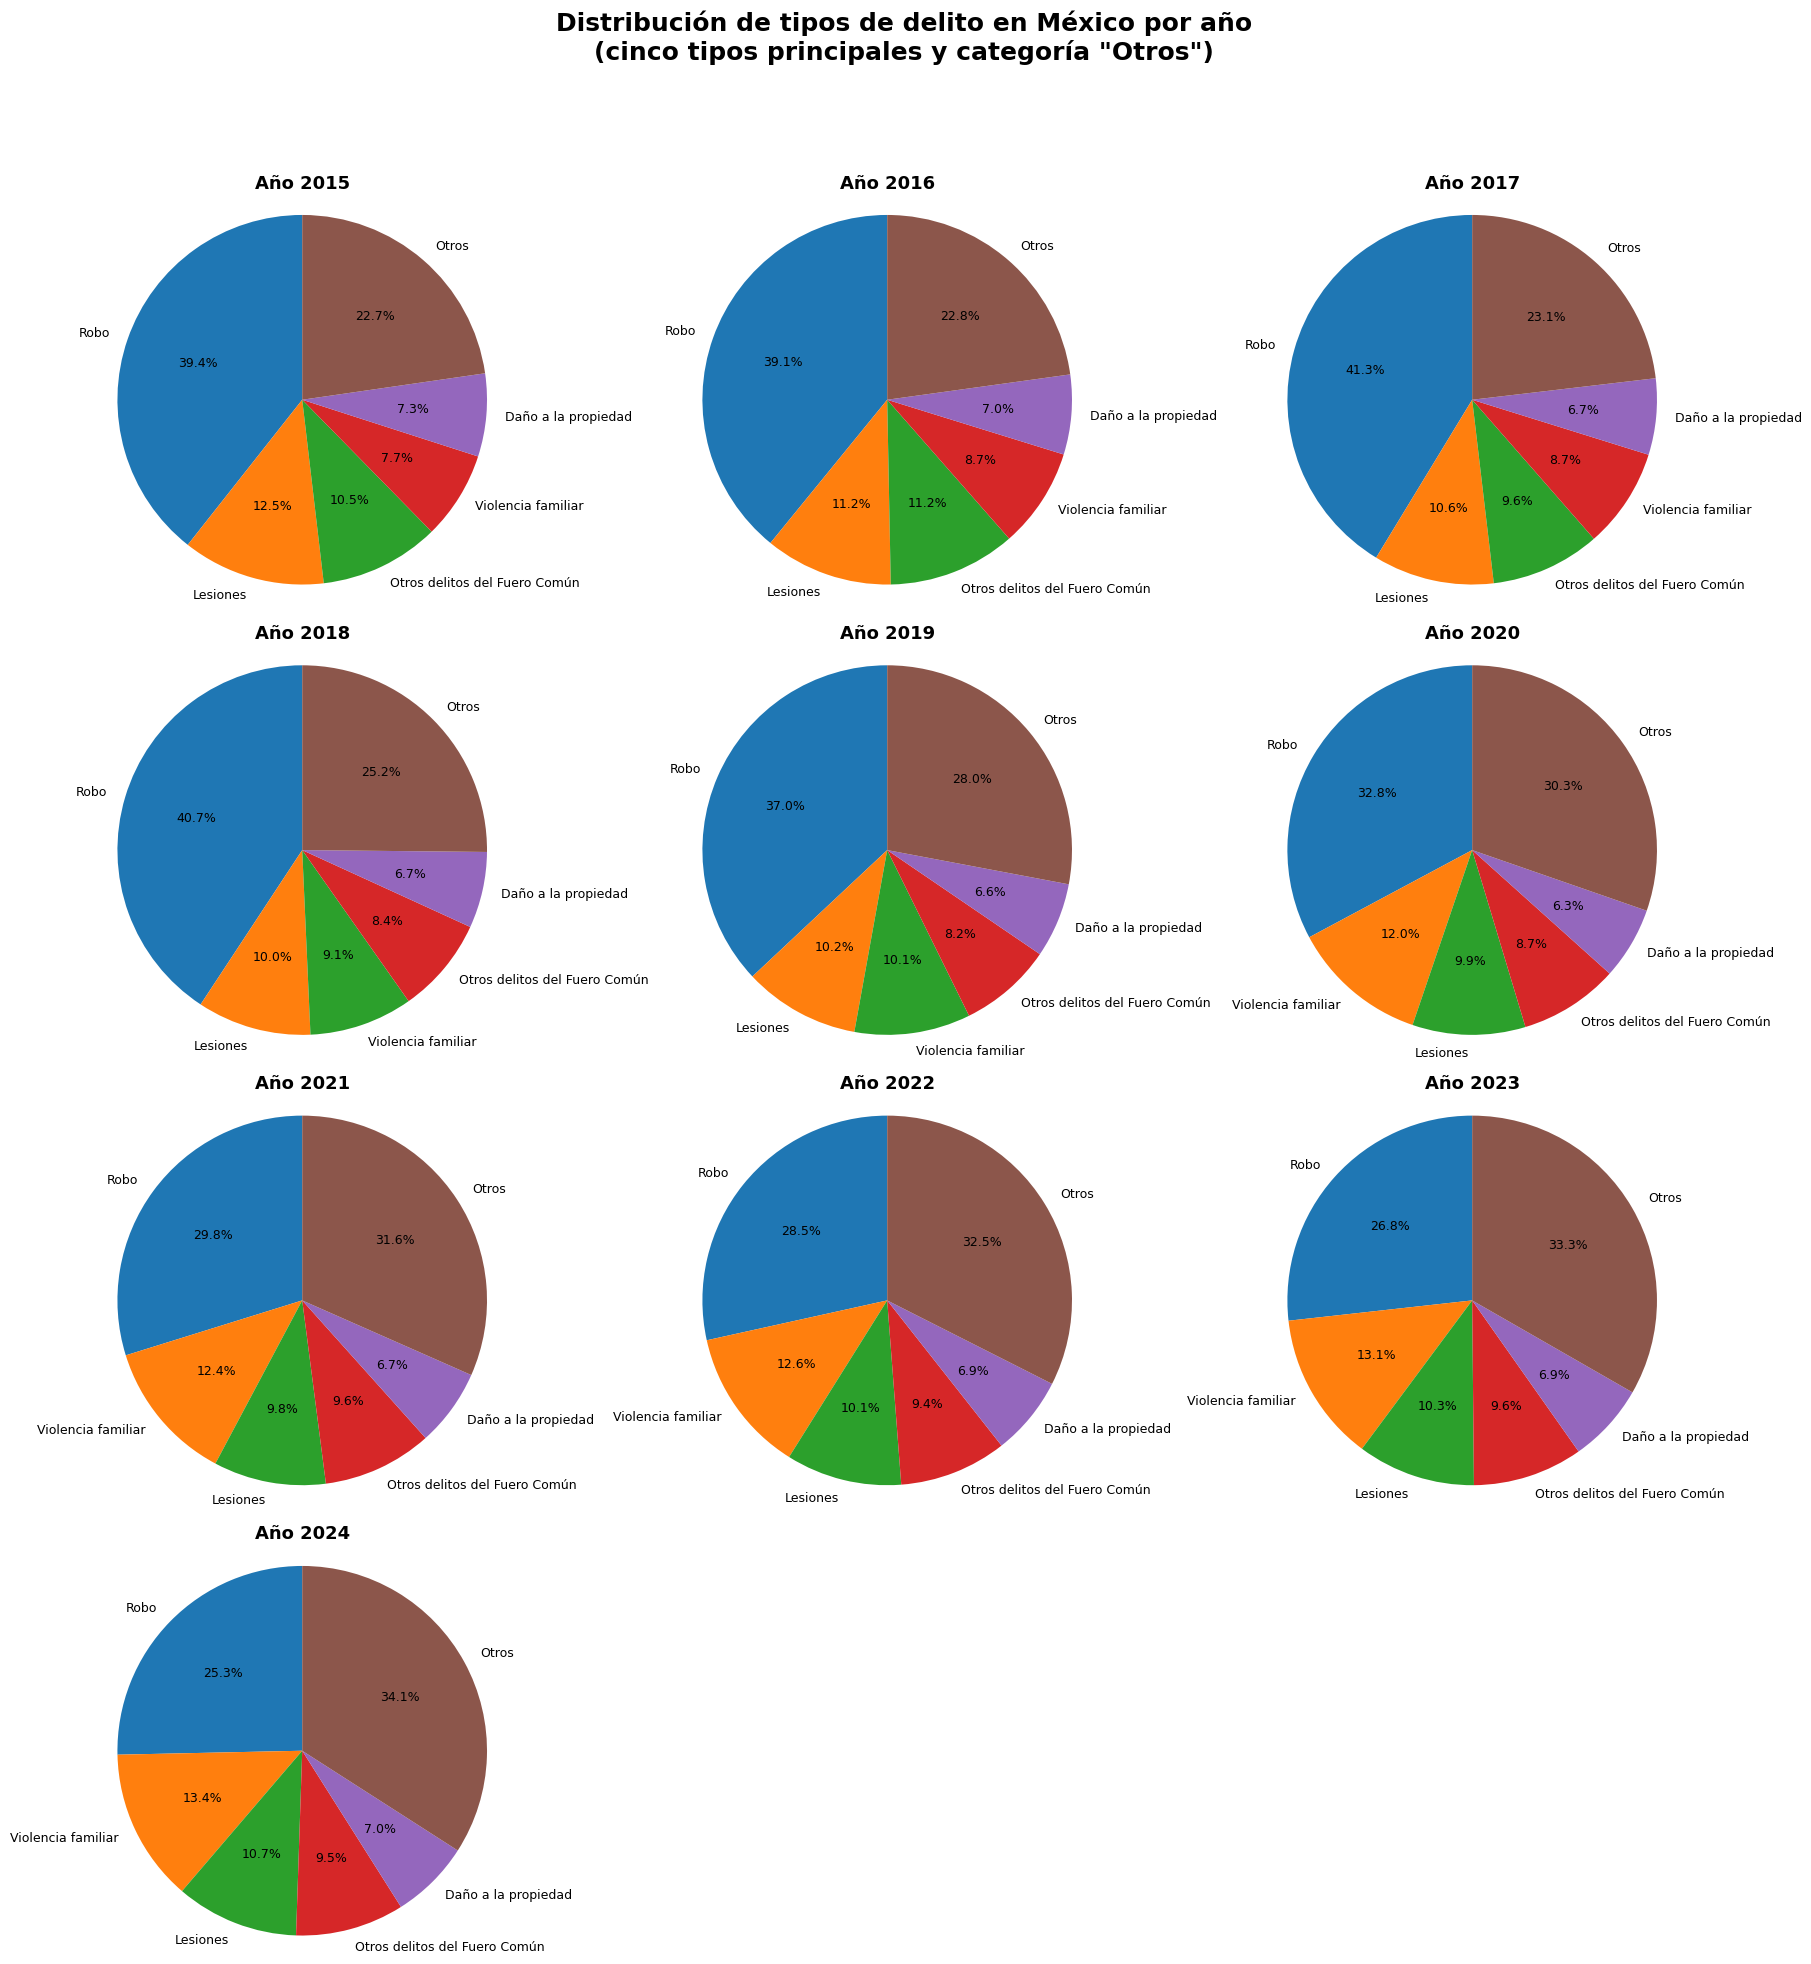

In [9]:
import math
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Preparación de los datos
# ---------------------------------------------------------

# Convertir fecha a datetime
df['fecha'] = pd.to_datetime(
    df['fecha'],
    errors='coerce'
)

# Convertir frecuencia a valor numérico
df['frecuencia'] = pd.to_numeric(
    df['frecuencia'],
    errors='coerce'
).fillna(0)

# Eliminar registros sin fecha válida
df_graficas = df.dropna(
    subset=['fecha', 'tipo_de_delito']
).copy()

# Obtener el año a partir de la fecha
df_graficas['anio'] = df_graficas['fecha'].dt.year

# Lista ordenada de años
anios = sorted(df_graficas['anio'].unique())

# ---------------------------------------------------------
# Configurar los subplots
# ---------------------------------------------------------

columnas = 3
filas = math.ceil(len(anios) / columnas)

fig, axes = plt.subplots(
    filas,
    columnas,
    figsize=(18, filas * 5)
)

# Convertir axes en un arreglo plano, incluso si solo hay una fila
axes = axes.flatten()

# ---------------------------------------------------------
# Crear una gráfica de pastel por cada año
# ---------------------------------------------------------

for i, anio in enumerate(anios):

    # Filtrar los registros del año actual
    df_anio = df_graficas.loc[
        df_graficas['anio'] == anio
    ].copy()

    # Sumar la frecuencia por tipo de delito
    resumen_delitos = (
        df_anio
        .groupby(
            'tipo_de_delito',
            as_index=False
        )['frecuencia']
        .sum()
        .sort_values(
            by='frecuencia',
            ascending=False
        )
    )

    # Conservar los cinco tipos más frecuentes
    top_5 = resumen_delitos.head(5).copy()

    # Sumar el resto de los delitos en la categoría "Otros"
    total_otros = resumen_delitos.iloc[5:]['frecuencia'].sum()

    # Agregar "Otros" solamente cuando tenga un valor mayor que cero
    if total_otros > 0:
        otros = pd.DataFrame({
            'tipo_de_delito': ['Otros'],
            'frecuencia': [total_otros]
        })

        datos_grafica = pd.concat(
            [top_5, otros],
            ignore_index=True
        )
    else:
        datos_grafica = top_5

    # Crear la gráfica de pastel
    axes[i].pie(
        datos_grafica['frecuencia'],
        labels=datos_grafica['tipo_de_delito'],
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 9}
    )

    axes[i].set_title(
        f'Año {int(anio)}',
        fontsize=13,
        fontweight='bold'
    )

    # Mantener el pastel circular
    axes[i].axis('equal')

# ---------------------------------------------------------
# Ocultar subplots que no se utilizaron
# ---------------------------------------------------------

for j in range(len(anios), len(axes)):
    axes[j].set_visible(False)

# ---------------------------------------------------------
# Título general y presentación
# ---------------------------------------------------------

fig.suptitle(
    'Distribución de tipos de delito en México por año\n'
    '(cinco tipos principales y categoría "Otros")',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)

plt.show()

---
#### Calcula la tasa por 100,000 habitantes
##### Tasa por 100,000 habitantes
Mostrar el total de delitos en una entidad no nos sirve de mucho. Es mucho más útil calcular la tasa de incidencia delictiva por cada 100,000 habitantes

$$
tasa = \frac{delitos\space totales}{población} \times 100,000
$$

Esta tasa la podemos anualizar multiplicándola por un factor de 12
$$
tasa\space anualizada = tasa \times 12
$$

Población por entidad federativa según [la encuesta intercensal 2015](https://www.inegi.org.mx/programas/intercensal/2015/)

No tienes que descargar nada. Ya están los datos en la carpeta data

In [10]:
import pandas as pd

# Cargar población por entidad
pobs = pd.read_csv(
    'data/poblacion_entidades_2015.csv',
    encoding='iso-8859-1',
    sep=';'
)

# Conservar únicamente las columnas necesarias
pobs = pobs[
    ['Cve_Entidad', 'Entidad', 'Poblacion']
].copy()

# Renombrar columnas
pobs = pobs.rename(
    columns={
        'Cve_Entidad': 'clave_entidad',
        'Entidad': 'entidad',
        'Poblacion': 'poblacion'
    }
)

# Limpiar espacios en los nombres de las entidades
pobs['entidad'] = pobs['entidad'].str.strip()

# Convertir población a número
# Esto también elimina separadores como comas, si existieran
pobs['poblacion'] = pd.to_numeric(
    pobs['poblacion']
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.strip(),
    errors='coerce'
)

# Eliminar registros sin población válida
pobs = pobs.dropna(
    subset=['entidad', 'poblacion']
).copy()

# Evitar divisiones entre cero
pobs = pobs.loc[
    pobs['poblacion'] > 0
].copy()

# Revisar el resultado
display(pobs.head())
print(pobs.dtypes)
print(f'Número de entidades: {pobs["entidad"].nunique()}')

,clave_entidad,entidad,poblacion
0,1,Aguascalientes,1312544.0
1,2,Baja California,3315766.0
2,3,Baja California Sur,712029.0
3,4,Campeche,899931.0
4,5,Coahuila de Zaragoza,5217908.0


clave_entidad      int64
entidad           object
poblacion        float64
dtype: object
Número de entidades: 32


In [7]:
# 1. Unir el DataFrame de delitos con el de población
# df tiene 'clave_ent' y pobs tiene 'clave_entidad'
df_tasas = df.merge(pobs, left_on='clave_ent', right_on='clave_entidad')

# Limpiamos columnas redundantes o con sufijos y renombramos para claridad
df_tasas = df_tasas.drop(columns=['clave_entidad', 'entidad_y']).rename(columns={'entidad_x': 'entidad'})

# 2. Calcular la tasa por cada 100,000 habitantes
df_tasas['tasa'] = (df_tasas['frecuencia'] / df_tasas['poblacion']) * 100000

# 3. Anualizar la tasa (multiplicar por 12)
df_tasas['tasa_anualizada'] = df_tasas['tasa'] * 12

print("DataFrame de tasas calculadas:")
display(df_tasas.head())


DataFrame de tasas calculadas:


,anio,clave_ent,entidad,tipo_de_delito,nombre_mes,fecha,frecuencia,poblacion,tasa,tasa_anualizada
0,2015,1,Aguascalientes,Aborto,abril,2015-04-01,0.0,1312544.0,0.000000,0.000000
1,2015,1,Aguascalientes,Aborto,agosto,2015-08-01,0.0,1312544.0,0.000000,0.000000
2,2015,1,Aguascalientes,Aborto,diciembre,2015-12-01,0.0,1312544.0,0.000000,0.000000
3,2015,1,Aguascalientes,Aborto,enero,2015-01-01,0.0,1312544.0,0.000000,0.000000
4,2015,1,Aguascalientes,Aborto,febrero,2015-02-01,3.0,1312544.0,0.228564,2.742765


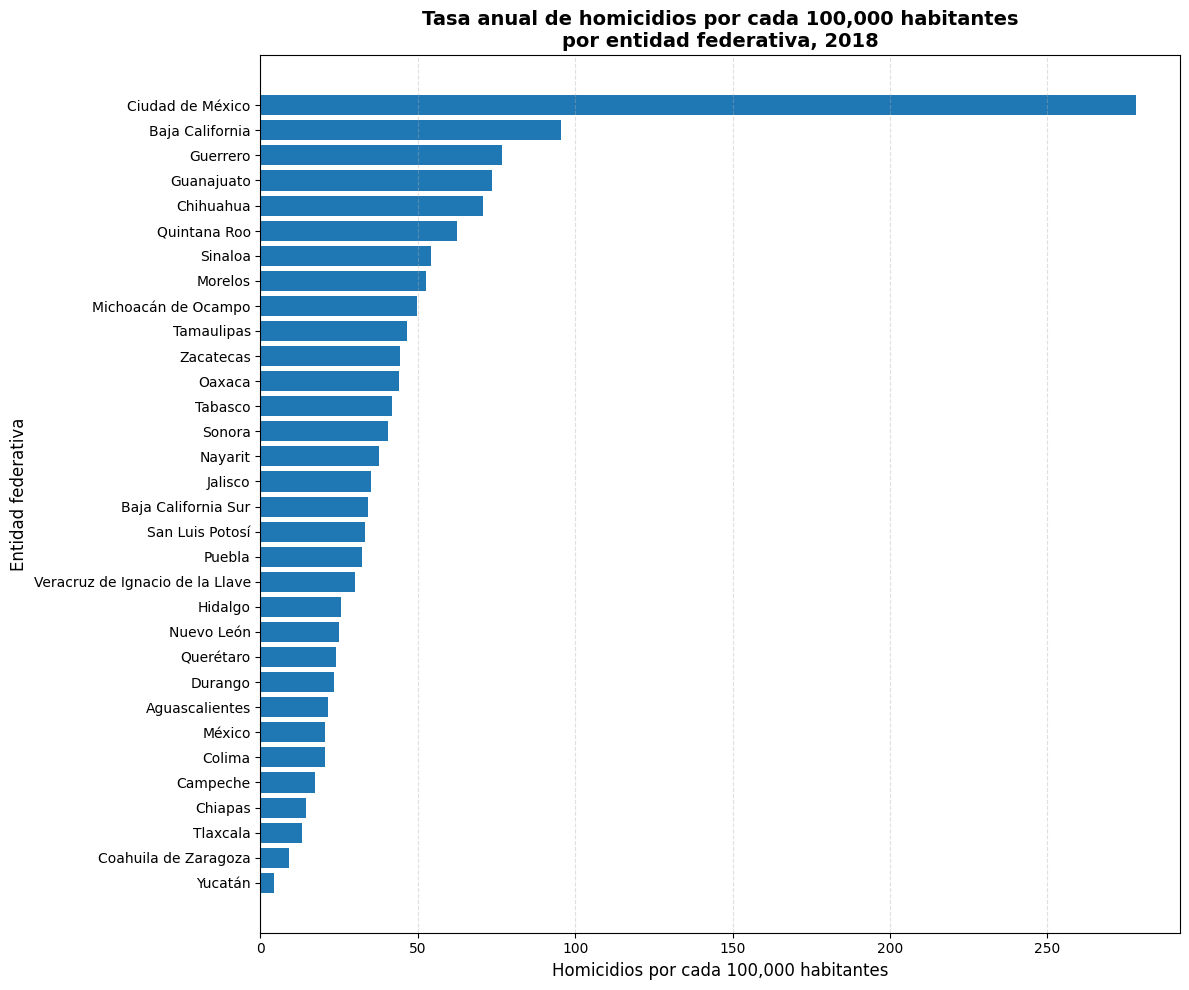

Top 5 de entidades con mayor tasa de homicidios en 2018:


,entidad,homicidios_totales,poblacion,tasa_100mil
0,Ciudad de México,1979.0,711235.0,278.248399
1,Baja California,3169.0,3315766.0,95.573692
2,Guerrero,2716.0,3533251.0,76.869716
3,Guanajuato,4298.0,5853677.0,73.423935
4,Chihuahua,2089.0,2954915.0,70.695773


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Preparar homicidios
# ---------------------------------------------------------

homicidios = df.loc[
    df['tipo_de_delito'] == 'Homicidio',
    ['anio', 'entidad', 'frecuencia']
].copy()

# Asegurar que frecuencia sea numérica
homicidios['frecuencia'] = pd.to_numeric(
    homicidios['frecuencia'],
    errors='coerce'
).fillna(0)

# Limpiar nombres de entidad
homicidios['entidad'] = homicidios['entidad'].str.strip()

# ---------------------------------------------------------
# Calcular total anual de homicidios por entidad
# ---------------------------------------------------------

homicidios_anual = (
    homicidios
    .groupby(
        ['anio', 'entidad'],
        as_index=False
    )['frecuencia']
    .sum()
    .rename(
        columns={
            'frecuencia': 'homicidios_totales'
        }
    )
)

# ---------------------------------------------------------
# Unir con población
# ---------------------------------------------------------

homicidios_anual = homicidios_anual.merge(
    pobs[['entidad', 'poblacion']],
    on='entidad',
    how='left',
    validate='many_to_one'
)

# Revisar entidades que no encontraron población
sin_poblacion = homicidios_anual.loc[
    homicidios_anual['poblacion'].isna(),
    'entidad'
].unique()

if len(sin_poblacion) > 0:
    print('Entidades sin población asociada:')
    print(sin_poblacion)

# Eliminar registros sin población válida
homicidios_anual = homicidios_anual.dropna(
    subset=['poblacion']
).copy()

# ---------------------------------------------------------
# Calcular tasa anual por cada 100,000 habitantes
# ---------------------------------------------------------

homicidios_anual['tasa_100mil'] = (
    homicidios_anual['homicidios_totales']
    / homicidios_anual['poblacion']
) * 100_000

# ---------------------------------------------------------
# Seleccionar 2018 y ordenar
# ---------------------------------------------------------

homicidios_2018 = (
    homicidios_anual.loc[
        homicidios_anual['anio'] == 2018
    ]
    .sort_values(
        by='tasa_100mil',
        ascending=True
    )
    .copy()
)

# ---------------------------------------------------------
# Graficar
# ---------------------------------------------------------

plt.figure(figsize=(12, 10))

plt.barh(
    homicidios_2018['entidad'],
    homicidios_2018['tasa_100mil']
)

plt.title(
    'Tasa anual de homicidios por cada 100,000 habitantes\n'
    'por entidad federativa, 2018',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Homicidios por cada 100,000 habitantes',
    fontsize=12
)

plt.ylabel(
    'Entidad federativa',
    fontsize=12
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Mostrar los cinco estados con mayor tasa
# ---------------------------------------------------------

top_5_2018 = homicidios_2018.sort_values(
    by='tasa_100mil',
    ascending=False
).head(5)

print(
    'Top 5 de entidades con mayor tasa de homicidios en 2018:'
)

display(
    top_5_2018[
        [
            'entidad',
            'homicidios_totales',
            'poblacion',
            'tasa_100mil'
        ]
    ].reset_index(drop=True)
)